**BEUST Léna**

________




# Seq2seq: Machine translation with pytorch and torchtext

In [4]:
!pip install torchtext==0.6.0

import torch # torch==1.8.0
import torch.nn.functional as F
from torch import nn
from torchsummary import summary
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
import torch.optim as optim

from torchtext.datasets import Multi30k # torchtext==0.6.0
from torchtext.data import Field, BucketIterator

import spacy
import numpy as np
import math
import random
import matplotlib.pyplot as plt
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.8 MB/s eta 0:00:00


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

This notebook trains  seq2seq models for German to English translation, using PyTorch and torchtext. Yet, this kind of models can be applied on any problem that requires going from one sequence to another, e.g., text summarization and visual question answering (VQA).

The encoder-decoder architecture represents one of the most common used baseline for seq2seq models. This architecture commonly use a RNN to encode the input sentence into a single vector, namely <em>context vector</em> (the final hidden state of the encoder). This vector is then decode by a second RNN, which will be learned to generate the output sentence (one word at a time).

The models that we are implementing here are from the [Sequence to Sequence Learning with Neural Networks](https://arxiv.org/pdf/1409.3215.pdf) paper.

## Preparing Data
`pytorchtext` will be used to help us do all the reuired data preprocessing. We'll also use `spacy` to assist in the tokenization of the data.\
A tokenizer is used to turn a string containing a sentence into a list of individual tokens, e.g., "guten morgen !" --> ["guten", "morgen", "!"].

spaCy has model for each language ("de_core_news_sm" for German and "en_core_web_sm" for English) which need to be loaded so we can access the tokenizer of each model.

<strong>Note:</strong> the models must first be downloaded using the following on the command line:

In [6]:
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 29.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


We can now load the models via spacy.load('de_core_news_sm')


In [7]:
spacy_de = spacy.load('de_core_news_sm')
spacy_en = spacy.load('en_core_web_sm')

In [8]:
def tokenize_de(text):

    """
    Tokenizes German text from a string into a list of strings (tokens) and reverses it
    """
    # i.e., the authors of the reference paper find it beneficial to reverse the
    #order of the input which they believe "introduces many short term dependencies
    #in the data that make the optimization problem much easier".

    return [tok.text for tok in spacy_de.tokenizer(text)][::-1]

def tokenize_en(text):
    """
    Tokenizes English text from a string into a list of strings (tokens)
    """
    # ... tokenize the English sentence here
    return [tok.text for tok in spacy_en.tokenizer(text)][::-1]


torchtext's `Field` handles how data should be processed:

In [9]:
SRC = Field(tokenize = tokenize_de, #the tokenize argument to the correct tokenization function for each,
            init_token = '<sos>',   #The field also appends the "start of sequence" '<sos>'
            eos_token = '<eos>',   #and "end of sequence" '<eos>'
            lower = True)


# ... define the target Field here
TRG = Field(tokenize = tokenize_en, #the tokenize argument to the correct tokenization function for each,
            init_token = '<sos>',   #The field also appends the "start of sequence" '<sos>'
            eos_token = '<eos>',   #and "end of sequence" '<eos>'
            lower = True)


Now let's download the train, val and test data.
The used dataset in this work is the [Multi30k](https://github.com/multi30k/dataset). This dataset contains ~30k parallel English, German and French 12-word sentences.

In [27]:
import os
import ssl
import zipfile
import shutil
import gzip # New import for handling gzipped files

# Temporarily disable SSL certificate verification for downloads
ssl._create_default_https_context = ssl._create_unverified_context

# Define the target directory for Multi30k dataset files
data_root_dir = '.data'
multi30k_base_dir = os.path.join(data_root_dir, 'multi30k')
os.makedirs(multi30k_base_dir, exist_ok=True)

# URL for the Multi30k dataset zip archive on GitHub
zip_url = 'https://github.com/multi30k/dataset/archive/master.zip'
zip_filename = os.path.join(multi30k_base_dir, 'master.zip')
extracted_archive_base_dir = os.path.join(multi30k_base_dir, 'dataset-master')
source_raw_dir_in_archive = os.path.join(extracted_archive_base_dir, 'data', 'task1', 'raw')

# Map the filenames expected by Multi30k.splits to the actual gzipped filenames in the archive
# CORRECTED: Updated mapping based on os.listdir output and Multi30k.splits expectations
file_mapping = {
    'train.de': 'train.de.gz',
    'train.en': 'train.en.gz',
    'val.de': 'val.de.gz',
    'val.en': 'val.en.gz',
    'test2016.de': 'test_2016_flickr.de.gz', # Map to 'test2016.de' as expected by Multi30k.splits
    'test2016.en': 'test_2016_flickr.en.gz'  # Map to 'test2016.en' as expected by Multi30k.splits
}

# Check if all expected files already exist in multi30k_base_dir
all_files_exist = True
for filename_expected in file_mapping.keys():
    if not os.path.exists(os.path.join(multi30k_base_dir, filename_expected)):
        all_files_exist = False
        break

if not all_files_exist:
    print("Preparing Multi30k dataset manually...")

    # Download the zip file if it doesn't exist
    if not os.path.exists(zip_filename):
        print(f"Downloading {zip_filename}...")
        # Use a more robust download method if wget has issues, but for now assuming it works
        !wget -nc -P {multi30k_base_dir} {zip_url}
    else:
        print(f"{zip_filename} already exists, skipping download.")

    # Extract the zip file if the extracted directory doesn't exist
    if not os.path.exists(extracted_archive_base_dir):
        print(f"Extracting {zip_filename}...")
        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            zip_ref.extractall(multi30k_base_dir)
    else:
        print(f"Zip already extracted to {extracted_archive_base_dir}, skipping extraction.")

    # --- Debugging: List contents of the raw directory ---
    if os.path.exists(source_raw_dir_in_archive):
        print(f"Contents of {source_raw_dir_in_archive}:")
        for item in os.listdir(source_raw_dir_in_archive):
            print(f"  - {item}")
    else:
        print(f"Warning: Directory {source_raw_dir_in_archive} does not exist.")
    print("--- End of directory listing ---")

    # Process and move the individual files
    print(f"Processing and moving files from {source_raw_dir_in_archive} to {multi30k_base_dir}...")
    for filename_expected, filename_actual_gz in file_mapping.items():
        src_gz_path = os.path.join(source_raw_dir_in_archive, filename_actual_gz)
        dst_path = os.path.join(multi30k_base_dir, filename_expected)

        if os.path.exists(dst_path):
            print(f"File {filename_expected} already exists in {multi30k_base_dir}, skipping.")
            continue

        if os.path.exists(src_gz_path):
            print(f"Decompressing and moving {filename_actual_gz} to {filename_expected}...")
            with gzip.open(src_gz_path, 'rt', encoding='utf-8') as gz_file:
                with open(dst_path, 'w', encoding='utf-8') as out_file:
                    shutil.copyfileobj(gz_file, out_file)
        else:
            print(f"Warning: Gzipped source file {src_gz_path} not found. Cannot create {filename_expected}.")
    print("Finished preparing files.")
else:
    print("All Multi30k files already present in expected format, skipping preparation.")

# Now, call Multi30k.splits, explicitly providing the path where the prepared files are located.
# Note: For torchtext==0.6.0, Multi30k.splits expects 'path' to be the directory containing
# the actual data files (e.g., train.de, train.en), not 'root' which is for download/extraction.
try:
    print("Attempting to load Multi30k dataset using torchtext.datasets.Multi30k.splits...")
    train_data, valid_data, test_data = Multi30k.splits(exts=('.de', '.en'),
                                                        fields=(SRC, TRG),
                                                        path=multi30k_base_dir,
                                                        test='test2016') # Specify the test split name
    print("Multi30k dataset loaded successfully.")
except Exception as e:
    print(f"Error loading Multi30k dataset: {e}")
    print("Double-check the file paths and contents.")

Preparing Multi30k dataset manually...
.data/multi30k/master.zip already exists, skipping download.
Zip already extracted to .data/multi30k/dataset-master, skipping extraction.
Contents of .data/multi30k/dataset-master/data/task1/raw:
  - val.en.gz
  - test_2016_flickr.cs.gz
  - test_2017_flickr.en.gz
  - test_2016_flickr.en.gz
  - train.fr.gz
  - train.de.gz
  - train.cs.gz
  - val.cs.gz
  - test_2017_flickr.de.gz
  - val.de.gz
  - test_2018_flickr.de.gz
  - test_2017_mscoco.en.gz
  - test_2018_flickr.cs.gz
  - test_2018_flickr.en.gz
  - test_2016_flickr.fr.gz
  - test_2016_flickr.de.gz
  - test_2017_mscoco.fr.gz
  - val.fr.gz
  - test_2018_flickr.fr.gz
  - test_2017_mscoco.de.gz
  - train.en.gz
  - test_2017_flickr.fr.gz
--- End of directory listing ---
Processing and moving files from .data/multi30k/dataset-master/data/task1/raw to .data/multi30k...
File train.de already exists in .data/multi30k, skipping.
File train.en already exists in .data/multi30k, skipping.
File val.de already

In [28]:
print(f"Number of training examples: {len(train_data.examples)}")
print(f"Number of validation examples: {len(valid_data.examples)}")
print(f"Number of testing examples: {len(test_data.examples)}")

Number of training examples: 29000
Number of validation examples: 1014
Number of testing examples: 1000


In [30]:
# ...  print an example and make sure that the source sentence is reversed
print(train_data.examples[0].src)


['.', 'büsche', 'vieler', 'nähe', 'der', 'in', 'freien', 'im', 'sind', 'männer', 'weiße', 'junge', 'zwei']


Next, we'll build the <em>vocabulary</em> for the source and target languages. The <em>vocabulary</em> is used to associate each unique token with an index.

In [31]:
SRC.build_vocab(train_data, min_freq = 2)

#min_freq argument only allows tokens that appear at least 2 times to be in our vocab

# ... build the target vocab here
TRG.build_vocab(train_data, min_freq = 2)


In [32]:
print(f"Unique tokens in source (de) vocabulary: {len(SRC.vocab)}")
print(f"Unique tokens in target (en) vocabulary: {len(TRG.vocab)}")

Unique tokens in source (de) vocabulary: 7853
Unique tokens in target (en) vocabulary: 5893


The final step of preparing the data is to create the iterators. These can be iterated on to return a batch of data which will have a `src` attribute and a `trg` attribute.

When we get a batch of examples using an iterator we need to make sure that all of the source sentences are padded to the same length, the same with the target sentences. Luckily, torchText iterators handle this for us!

In [33]:
#BucketIterator instead of the standard Iterator as it creates batches in such a way
#that it minimizes the amount of padding in both the source and target sentences.

BATCH_SIZE = 128

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    device = device)

## Building the Seq2Seq Model

**We build the model in 3 parts: The encoder, the decoder and a seq2seq model that ncapsulates the encoder and decoder and will provide a way to interface with each.**


### Encoder


The Encoder is a 2-layer LSTM (the ref. paper uses a 4-layer LSTM but for the sake of simplicity, i.e., training time, we'll only use 2 layers).\
So our encoder looks like this:

<img src="encoder.png" align="left"/>

In [35]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(input_dim, emb_dim)

        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout = dropout) #  PS: This time batch_first = False (by default)
                                                                          # because the torchtext data are in that
                                                                          # order (seq, batch, feature).

        self.dropout = nn.Dropout(dropout)

    def forward(self, src):

        #src = [src len, batch size]
        embedded = self.dropout(self.embedding(src))
        #embedded = [src len, batch size, emb dim]

        outputs, (hidden, cell) = self.rnn(embedded)


        #outputs = [src len, batch size, hid dim * n directions]
        #hidden = [n layers * n directions, batch size, hid dim]
        #cell = [n layers * n directions, batch size, hid dim]

        #outputs are always from the top hidden layer

        return hidden, cell

### Decoder

Next, we'll build our decoder, which will also be a 2-layer LSTM.

<img src="assets/decoder.png" align="left"/>

In [37]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()

        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(output_dim, emb_dim)

        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout = dropout)

        self.fc_out = nn.Linear(hid_dim, output_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell):

        #input = [batch size]
        #hidden = [n layers * n directions, batch size, hid dim]
        #cell = [n layers * n directions, batch size, hid dim]

        #n directions in the decoder will both always be 1, therefore:
        #hidden = [n layers, batch size, hid dim]
        #context = [n layers, batch size, hid dim]

        input = input.unsqueeze(0)
        #input = [1, batch size]

        embedded = self.dropout(self.embedding(input))
        #embedded = [1, batch size, emb dim]

        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))

        #output = [seq len, batch size, hid dim * n directions]
        #hidden = [n layers * n directions, batch size, hid dim]
        #cell = [n layers * n directions, batch size, hid dim]

        #seq len and n directions will always be 1 in the decoder, therefore:
        #output = [1, batch size, hid dim]
        #hidden = [n layers, batch size, hid dim]
        #cell = [n layers, batch size, hid dim]

        prediction = self.fc_out(output.squeeze(0))

        #prediction = [batch size, output dim]

        return prediction, hidden, cell

### Seq2Seq

For the final part of the implemenetation, we'll build the seq2seq model. This will handle:

* receiving the input/source sentence
* using the encoder to produce the context vectors
* using the decoder to produce the predicted output/target sentence

Our full model will look like this:


<img src="assets/seq2seq.png" align="left"/>

In [39]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

        assert encoder.hid_dim == decoder.hid_dim, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.n_layers == decoder.n_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, src, trg, teacher_forcing_ratio = 0.5):

        #src = [src len, batch size]
        #trg = [trg len, batch size]
        #teacher_forcing_ratio is probability to use teacher forcing
        #e.g. if teacher_forcing_ratio is 0.75 we use ground-truth inputs 75% of the time

        trg_len, batch_size = trg.size()
        trg_vocab_size = self.decoder.output_dim

        #tensor to store decoder outputs
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(src.device)

        #last hidden state of the encoder is used as the initial hidden state of the decoder
        hidden, cell = self.encoder(src)

        #first input to the decoder is the <sos> tokens
        input = trg[0,:]

        for t in range(1, trg_len):

            #insert input token embedding, previous hidden and previous cell states
            #receive output tensor (predictions) and new hidden and cell states
            output, hidden, cell = self.decoder(input, hidden, cell)

            #place predictions in a tensor holding predictions for each token
            outputs[t] = output

            #decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio

            #get the highest predicted token from our predictions
            top1 = output.argmax(1)

            #if teacher forcing, use actual next token as next input
            #if not, use predicted token
            input = trg[t] if teacher_force else top1

        return outputs

## Training the Seq2Seq Model

Now let's train our implemented model.

First, we'll initialize our model. As mentioned before, the input and output dimensions are defined by the size of the vocabulary. The embedding\
dimesions and dropout for the encoder and decoder can be different, but the number of layers and the size of the hidden/cell states must be the same.

We then define the encoder, decoder and then our Seq2Seq model.

In [41]:
INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)

model = Seq2Seq(enc, dec)

Next up is initializing the weights of our model. The authots of the ref. paper have initialized all weights from a uniform distribution between -0.08 and +0.08.

We initialize weights in PyTorch by creating a function which we `apply` to our model. When using `apply`, the `init_weights` function will be called on every module and sub-module within our model. For each module we loop through all of the parameters and sample them from a uniform distribution with `nn.init.uniform_`.

In [42]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(5893, 256)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.5)
    (fc_out): Linear(in_features=512, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

Next we define our optimizer and loss function. Our loss function calculates the average loss per token, however by passing the index of the `<pad>` token as the `ignore_index` argument we ignore the loss whenever the target token is a padding token.

In [43]:
optimizer = optim.Adam(model.parameters())

TRG_PAD_IDX = TRG.vocab.stoi[TRG.pad_token]
criterion = nn.CrossEntropyLoss(ignore_index = TRG_PAD_IDX)

Next, we'll define our training loop.

In [44]:
def train(model, iterator, optimizer, criterion, clip):

    model.train()

    epoch_loss = 0

    for i, batch in enumerate(tqdm(iterator)):

        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()

        output = model(src, trg)

        #trg = [trg len, batch size]
        #output = [trg len, batch size, output dim]

        output_dim = output.shape[-1]

        output = output[1:].view(-1, output_dim)
        trg = trg[1:].flatten()

        #trg = [(trg len - 1) * batch size]
        #output = [(trg len - 1) * batch size, output dim]

        loss = criterion(output, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

Our evaluation loop is similar to our training loop, however as we aren't updating any parameters we don't need to pass an optimizer or a clip value.\
We must remember to set the model to evaluation mode with model.eval(). This will turn off dropout (and batch normalization, if used).\
We use the new `with torch.no_grad()` context manager to ensure no gradients are calculated within the block. This reduces memory consumption and speeds things up.

In [45]:
def evaluate(model, iterator, criterion):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for i, batch in enumerate(iterator):

            src = batch.src
            trg = batch.trg

            output = model(src, trg, 0) #turn off teacher forcing

            #trg = [trg len, batch size]
            #output = [trg len, batch size, output dim]

            output_dim = output.shape[-1]

            output = output[1:].view(-1, output_dim)
            trg = trg[1:].flatten()

            #trg = [(trg len - 1) * batch size]
            #output = [(trg len - 1) * batch size, output dim]

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

We can finally start training our model!

At each epoch, we'll be checking if our model has achieved the best validation loss so far. If it has, we'll update our best validation loss and save the parameters of our model (called `state_dict` in PyTorch). Then, when we come to test our model, we'll use the saved parameters used to achieve the best validation loss.

We'll be printing out both the loss and the perplexity at each epoch. It is easier to see a change in perplexity than a change in loss as the numbers are much bigger.

In [46]:
N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, valid_iterator, criterion)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'seq2seq-model.pt')

    # ... print the epoch number and the time it takes here, e.g., Epoch: 08 | Time: 0m 27s

    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

  0%|          | 0/227 [00:00<?, ?it/s]

	Train Loss: 4.991 | Train PPL: 147.049
	 Val. Loss: 4.790 |  Val. PPL: 120.305


  0%|          | 0/227 [00:00<?, ?it/s]

	Train Loss: 4.473 | Train PPL:  87.589
	 Val. Loss: 4.737 |  Val. PPL: 114.052


  0%|          | 0/227 [00:00<?, ?it/s]

...

	Train Loss: 3.437 | Train PPL:  31.082
	 Val. Loss: 4.115 |  Val. PPL:  61.236


  0%|          | 0/227 [00:00<?, ?it/s]

	Train Loss: 3.248 | Train PPL:  25.740
	 Val. Loss: 4.039 |  Val. PPL:  56.753


  0%|          | 0/227 [00:00<?, ?it/s]

	Train Loss: 3.089 | Train PPL:  21.960
	 Val. Loss: 3.903 |  Val. PPL:  49.569


In [ ]:
N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

train_losses = []
valid_losses = []

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'seq2seq-model.pt')

    print(f"Epoch: {epoch+1:02} | Time: {int(epoch_mins)}m {int(epoch_secs)}s")
    print(f"\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}")
    print(f"\tValid Loss: {valid_loss:.3f} | Valid PPL: {math.exp(valid_loss):7.3f}")


We'll load the parameters (`state_dict`) that gave our model the best validation loss and run it the model on the test set.

In [47]:
model.load_state_dict(torch.load('seq2seq-model.pt'))

test_loss = evaluate(model, test_iterator, criterion)

print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')

| Test Loss: 3.975 | Test PPL:  53.259 |


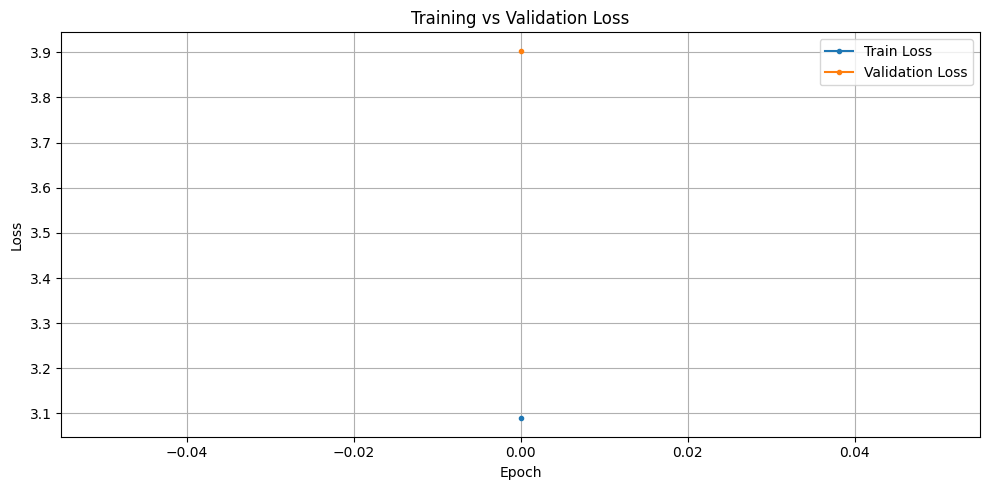

In [48]:
# ... plot the training and test loss here (optional)
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Train Loss", marker="o", markersize=3)
plt.plot(valid_loss, label="Validation Loss", marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
from datasets import load_dataset
dataset = load_dataset("bentrevett/multi30k")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [51]:
# ... print a GE->EN output example here
def translate_sentence(sentence, vocab_src, vocab_trg, model, device, max_len=50):
    model.eval()

    # tokenize and encode
    tokens = tokenize_de(sentence) if isinstance(sentence, str) else sentence
    src_indices = encode(tokens, vocab_src)
    src_tensor = torch.LongTensor(src_indices).unsqueeze(1).to(device)
    src_mask = model.make_src_mask(src_tensor)

    with torch.no_grad():
        enc_src = model.encoder(src_tensor, src_mask)

    trg_indices = [SOS_IDX]
    for _ in range(max_len):
        trg_tensor = torch.LongTensor(trg_indices).unsqueeze(1).to(device)
        trg_mask = model.make_trg_mask(trg_tensor)

        with torch.no_grad():
            output, _ = model.decoder(trg_tensor, enc_src, trg_mask, src_mask)

        pred_token = output.argmax(2)[-1].item()
        trg_indices.append(pred_token)

        if pred_token == EOS_IDX:
            break

    trg_tokens = [itos_trg[i] for i in trg_indices[1:-1]]  # strip <sos>/<eos>
    return " ".join(trg_tokens)


# ── Example ───────────────────────────────────────────────────────────────────
example = dataset["test"][0]
src_sentence = example["de"]
ref_sentence = example["en"]

translation = translate_sentence(src_sentence, vocab_src, vocab_trg, model, device)

print(f"Source (DE) : {src_sentence}")
print(f"Translation : {translation}")
print(f"Reference   : {ref_sentence}")

NameError: name 'vocab_src' is not defined